In [6]:
# Install the Kaggle library to interact with Kaggle API
!pip install kaggle

In [7]:
import os
from google.colab import userdata

# Create .kaggle directory to store API credentials
!mkdir -p ~/.kaggle

# Write Kaggle API credentials from Colab secrets to kaggle.json
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write('{"username":"' + userdata.get('Kaggle_UserName') + '","key":"' + userdata.get('Kaggle_API_Key') + '"}')

# Set secure permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
# Define the Kaggle dataset identifier
dataset_id = 'joniarroba/noshowappointments'

# Download the dataset files into the current directory
!kaggle datasets download -d {dataset_id}

# Unzip the downloaded archive (assuming it's named 'noshowappointments.zip')
!unzip -o noshowappointments.zip

Dataset URL: https://www.kaggle.com/datasets/joniarroba/noshowappointments
License(s): CC-BY-NC-SA-4.0
100% 2.40M/2.40M [00:00<00:00, 195MB/s]

Archive:  noshowappointments.zip
  inflating: KaggleV2-May-2016.csv   


In [9]:
#Import Patient Noshow data using pandas and do Exploratory Data Analysis
import pandas as pd

# Load the main CSV file into a pandas DataFrame
noshow_Patientdata = pd.read_csv('KaggleV2-May-2016.csv')

# Convert 'ScheduledDay' and 'AppointmentDay' to datetime objects
noshow_Patientdata['ScheduledDay'] = pd.to_datetime(noshow_Patientdata['ScheduledDay'])
noshow_Patientdata['AppointmentDay'] = pd.to_datetime(noshow_Patientdata['AppointmentDay'])

# Print the unique value counts for each stored column
object_col=noshow_Patientdata.select_dtypes(include=['object'])
display(f"Total number of object type columns: {object_col.shape[1]}")
display("Unique values per object column:",object_col.nunique())

# Display the first 5 rows of the DataFrame to confirm data loading
display("Top 5 row:", noshow_Patientdata.head())
display("Row and column", noshow_Patientdata.shape)
display("No. of Patient with No show as Yes and No", noshow_Patientdata['No-show'].value_counts())
display("No of columns with Dtype", noshow_Patientdata.info())
display("Stats summary of all columns", noshow_Patientdata.describe())
display("Count missing values per column",noshow_Patientdata.isnull().sum())

# Fix age outliers — this dataset has age -1 and 115 (real errors)
display("Age min:", noshow_Patientdata['Age'].min(), "Age max:", noshow_Patientdata['Age'].max())
noshow_Patientdata = noshow_Patientdata[(noshow_Patientdata['Age'] >= 0) & (noshow_Patientdata['Age'] <= 100)]
display("Rows after age fix:", len(noshow_Patientdata))

'Total number of object type columns: 3'

'Unique values per object column:'

,0
Gender,2
Neighbourhood,81
No-show,2


'Top 5 row:'

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


...

-1

'Age max:'

115

'Rows after age fix:'

110519

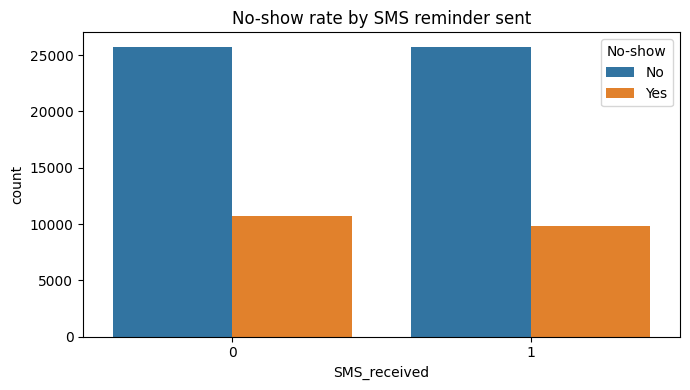

/tmp/ipykernel_7393/1091935952.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  noshow_by_wait = noshow_Patientdata.groupby('wait_bucket')['No-show'].apply(


,Wait bucket,No-show %
0,0–7d,25.005972
1,8–30d,31.999279
2,31–60d,34.073596
3,60d+,28.826531


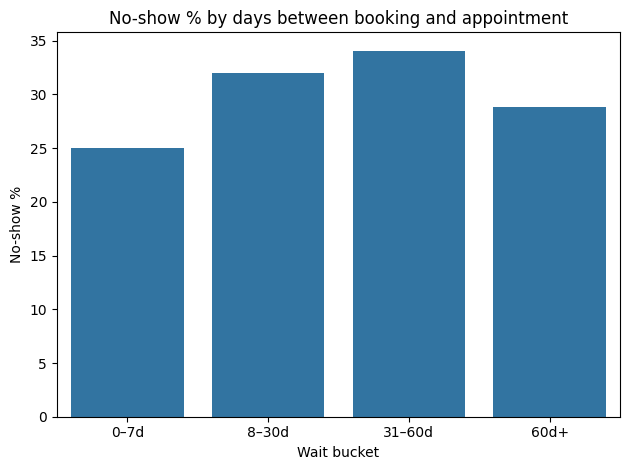

In [10]:
# Getting insights based on Patient No show data using seaborn

pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
import seaborn as sns

#Creating days_wait to determine difference between appointment date & scheduled data
noshow_Patientdata['days_wait']= (noshow_Patientdata['AppointmentDay'] - noshow_Patientdata['ScheduledDay']).dt.days
noshow_Patientdata = noshow_Patientdata[noshow_Patientdata['days_wait'] >= 0]

# Chart 1: No-show rate by SMS received
plt.figure(figsize=(7,4))
sns.countplot(data=noshow_Patientdata, x='SMS_received', hue='No-show')
plt.title('No-show rate by SMS reminder sent')
plt.tight_layout()
plt.show()

# Chart 2: No-show rate by wait time bucket
noshow_Patientdata['wait_bucket'] = pd.cut(noshow_Patientdata['days_wait'], bins=[0,7,30,60,200],
                            labels=['0–7d','8–30d','31–60d','60d+'])
noshow_by_wait = noshow_Patientdata.groupby('wait_bucket')['No-show'].apply(
    lambda x: (x=='Yes').mean() * 100).reset_index()
noshow_by_wait.columns = ['Wait bucket','No-show %']
display(noshow_by_wait)
sns.barplot(data=noshow_by_wait, x='Wait bucket', y='No-show %')
plt.title('No-show % by days between booking and appointment')
plt.tight_layout()
plt.show()

In [11]:
# Creating a simple model using Random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Encode target: No-show Yes=1, No=0
noshow_Patientdata['target'] = (noshow_Patientdata['No-show'] == 'Yes').astype(int)

# Encode gender: Female=1, Male=0
noshow_Patientdata['Gender_enc'] = (noshow_Patientdata['Gender'] == 'F').astype(int)

# Select features
features = ['Age', 'Gender_enc', 'Scholarship', 'Hipertension',
            'Diabetes', 'Alcoholism', 'SMS_received', 'days_wait']

X = noshow_Patientdata[features]
y = noshow_Patientdata['target']

#print("Feature matrix shape:", X.shape)
#print("No-show rate:", round(y.mean() * 100, 1), "%")
#display(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("=== Model Performance ===")
print(f"Classification Report:\n{classification_report(y_test, model.predict(X_test))}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, model.predict(X_test))}\n")

# Feature importance — print which features matter most
import numpy as np
importances = pd.Series(model.feature_importances_, index=features)
print("\nFeature importance (highest = most predictive):")
print(importances.sort_values(ascending=False))

=== Model Performance ===
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.85      0.79     10276
           1       0.37      0.21      0.27      4115

    accuracy                           0.67     14391
   macro avg       0.55      0.53      0.53     14391
weighted avg       0.63      0.67      0.64     14391

Confusion Matrix:
[[8765 1511]
 [3240  875]]


Feature importance (highest = most predictive):
Age             0.519272
days_wait       0.429368
Gender_enc      0.012419
SMS_received    0.010628
Hipertension    0.008650
Scholarship     0.007700
Diabetes        0.006175
Alcoholism      0.005788
dtype: float64


In [12]:
import pickle

# Ensure the 'model' variable is defined by running the preceding cell (rNE-zkm4XtsK) first.
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Patient_noshow_model.pkl saved ✓")
print("File size:", round(import_size := __import__('os').path.getsize('Patient_noshow_model.pkl') / 1024, 1), "KB")

Patient_noshow_model.pkl saved ✓
File size: 0.0 KB


In [13]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Checking if my .pkl file has model loaded correctly
with open("model.pkl", "rb") as f:          # rb = read-binary
    loaded_model = pickle.load(f)

import numpy as np
test_input = np.array([[35, 1, 0, 0, 0, 0, 1, 7]])  # sample patient
prob = loaded_model.predict_proba(test_input)[0][1]
print(f"Test prediction: {prob:.1%} probability of no-show")
print("Model loads correctly ✓" if 0 < prob < 1 else "Something is wrong")

Test prediction: 33.7% probability of no-show
Model loads correctly ✓


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
# Write this down — you will need it for requirements.txt in Week 6
# Output(Copied from output post running the file)- scikit-learn version: 1.6.1

scikit-learn version: 1.6.1
